# Jarvis Context-Aware Mobile Agent: Telemetry Analysis & OpenRouter Intent Reasoning

**Target Device**: Poco X4 Pro 5G (Qualcomm Snapdragon 695)  
**Vehicle**: Royal Enfield Hunter 350  
**Cloud Reasoning Infrastructure**: OpenRouter API (`meta-llama/llama-3.1-8b-instruct`, `google/gemma-4-26b-a4b-it`, `z-ai/glm-4.5-air`)  
**Architecture**: Tiered Edge Telemetry with Dual-Tier Cloud Reasoning (BRD FR-01 to FR-12)

---

### Architecture Overview

```
 ┌────────────────────────────────────────────────────────┐
 │            POCO X4 PRO 5G (Edge Node)                  │
 │  • 50 Hz Raw IMU (Accel/Gyro) & 1m GNSS GPS            │
 │  • Bounded Burst & Edge Feature Extraction (Stage 3)   │
 │  • Zero LLM Overhead on Handset                        │
 └──────────────────────────┬─────────────────────────────┘
                            │ Transmits Kilobytes of JSON Metadata
                            ▼
 ┌────────────────────────────────────────────────────────┐
 │           OPENROUTER DUAL-TIER CLOUD REASONING         │
 │                                                        │
 │  [Tier 1: Context Reasoner]                            │
 │  • Resolves vehicle physical state (Hunter 350 vs Walk)│
 │  • Semantic place & Stop-Shop-Return dwell resolution  │
 │                                                        │
 │  [Tier 2: Agentic Orchestrator]                        │
 │  • Deduces user intent from natural language           │
 │  • Allow-listed Function Registry (Reminders/Tasks)    │
 │  • Executes CRUD operations & triggers automations     │
 └────────────────────────────────────────────────────────┘
```


## 1. Environment Setup & Library Imports


In [1]:
import os
import sys
import glob
import json
import uuid
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
from dotenv import load_dotenv

# Configure matplotlib dark aesthetic
plt.style.use('dark_background')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = '#475569'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.color'] = '#334155'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.6

# Resolve project paths
NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name != 'notebooks':
    NOTEBOOK_DIR = NOTEBOOK_DIR / 'notebooks'
PROJECT_ROOT = NOTEBOOK_DIR.parent
BACKEND_DIR = PROJECT_ROOT / 'backend'
DATA_DIR = NOTEBOOK_DIR / 'data'

# Add backend to sys.path to access Jarvis cloud modules
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

# Load OpenRouter API credentials
load_dotenv(BACKEND_DIR / '.env')
api_key = os.getenv('OPENROUTER_API_KEY')
print(f"[✓] Backend environment loaded from: {BACKEND_DIR}")
print(f"[✓] OpenRouter API Key configured: {'YES (sk-or-v1-...)' if api_key else 'NO'}")


[✓] Backend environment loaded from: C:\Users\sampa\Dev\Jarvis\backend
[✓] OpenRouter API Key configured: YES (sk-or-v1-...)


## 2. Telemetry Ingestion: Real Data Pulled from Poco X4 Pro 5G

The mobile collector app records two synchronized streams:
1. **High Telemetry (CSV)**: Continuous 50 Hz raw Accelerometer ($X, Y, Z$), User Acceleration, and Gyroscope ($	ext{Rot}_X, 	ext{Rot}_Y, 	ext{Rot}_Z$) alongside high-accuracy 1-meter GNSS GPS.
2. **Low Telemetry (JSON)**: Edge-extracted vibration features, trajectory checkpoints, bounding box, and journey kinematics.


In [2]:
# Locate latest CSV recording in notebooks/data
csv_files = sorted(glob.glob(str(DATA_DIR / "*.csv")))
if not csv_files:
    raise FileNotFoundError(f"No telemetry CSV files found in {DATA_DIR}")

selected_csv = csv_files[-1]
session_id = Path(selected_csv).stem
print(f"Latest Recording Session: {session_id}")
print(f"CSV File    : {Path(selected_csv).name} ({os.path.getsize(selected_csv):,} bytes)")

json_path = DATA_DIR / f"{session_id}_summary.json"
summary_json = None
if json_path.exists():
    with open(json_path, "r", encoding="utf-8") as jf:
        summary_json = json.load(jf)
    print(f"Summary JSON: {json_path.name} ({os.path.getsize(json_path):,} bytes)")

# Ingest high telemetry dataframe
df = pd.read_csv(selected_csv)
duration_sec = df['relative_sec'].max()
sampling_rate = len(df) / max(duration_sec, 0.001)

print(f"\n--- Session Ingestion Summary: {session_id} ---")
print(f"• Total Data Samples : {len(df):,}")
print(f"• Duration           : {duration_sec:.1f} s (~{duration_sec/60:.1f} min)")
print(f"• Mean Sampling Rate : {sampling_rate:.1f} Hz (target: 50.0 Hz)")
print(f"• Total Columns      : {len(df.columns)}")
df.head(3)


Latest Recording Session: jarvis_telemetry_20260908_164443
CSV File    : jarvis_telemetry_20260908_164443.csv (11,487,183 bytes)
Summary JSON: jarvis_telemetry_20260908_164443_summary.json (9,240 bytes)



--- Session Ingestion Summary: jarvis_telemetry_20260908_164443 ---
• Total Data Samples : 68,164
• Duration           : 679.8 s (~11.3 min)
• Mean Sampling Rate : 100.3 Hz (target: 50.0 Hz)
• Total Columns      : 21


,timestamp_ms,relative_sec,accel_x,accel_y,accel_z,user_accel_x,user_accel_y,user_accel_z,gyro_x,gyro_y,...,latitude,longitude,altitude_m,speed_mps,speed_kmh,bearing_deg,accuracy_m,label,mount_position,road_condition
0,1788866084084,0.322,-3.6781,4.7896,7.5645,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AUTO,POCKET_OR_MOUNT,NORMAL
1,1788866084091,0.329,-3.7260,4.8423,7.5501,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AUTO,POCKET_OR_MOUNT,NORMAL
2,1788866084196,0.434,-3.6302,4.8375,7.5932,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AUTO,POCKET_OR_MOUNT,NORMAL


## 3. Deterministic Edge Feature Extraction (BRD Stage 3)

In accordance with BRD Section 2.1 and Stage 3:
- **Root Mean Square (RMS)**: Measures vibration severity and kinetic energy:
  $$\text{RMS}_z = \sqrt{\frac{1}{N}\sum_{i=1}^N (a_{z,i} - g)^2}$$
- **Fast Fourier Transform (FFT) & Dominant Frequency**: Identifies engine firing harmonics:
  $$X(f) = \sum_{n=0}^{N-1} x[n] e^{-j 2\pi f n / N}$$
  *Royal Enfield Hunter 350*: Single-cylinder 349cc J-series engine produces characteristic low-frequency thumping between **6.0 Hz – 16.0 Hz** during idle and low-gear travel.
- **Zero-Crossing Rate (ZCR)**:
  $$\text{ZCR} = \frac{1}{2T} \sum_{i=1}^N |\text{sgn}(x_i) - \text{sgn}(x_{i-1})|$$
- **Spectral Entropy**: Quantifies vibration order vs noise (0 = pure tone / clean harmonic, 1 = random white noise):
  $$H = -\frac{1}{\log_2(K)} \sum_{k=1}^K p_k \log_2(p_k)$$


In [3]:
def compute_spectral_features(signal, fs=50.0):
    n = len(signal)
    centered = signal - np.mean(signal)
    yf = np.abs(rfft(centered))
    xf = rfftfreq(n, 1.0 / fs)

    # Ignore sub-0.5 Hz gravitational drift
    mask = xf >= 0.5
    valid_xf = xf[mask]
    valid_yf = yf[mask]
    
    peak_freq = float(valid_xf[np.argmax(valid_yf)])
    psd = valid_yf ** 2
    energy = float(np.sum(psd) / n)
    
    # Normalized spectral entropy
    psd_norm = psd / (np.sum(psd) + 1e-12)
    entropy = float(-np.sum(psd_norm * np.log2(psd_norm + 1e-12)) / np.log2(len(psd_norm)))
    return peak_freq, energy, entropy, xf, yf

def compute_zcr(signal, fs=50.0):
    centered = signal - np.mean(signal)
    crossings = np.nonzero(np.diff(centered > 0))[0]
    return float(len(crossings) / (len(signal) / fs))

# Extract features from dataset
accel_z = df['accel_z'].values
user_accel = np.sqrt(df['user_accel_x']**2 + df['user_accel_y']**2 + df['user_accel_z']**2).values
gyro_mag = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2).values

dom_freq, energy, entropy, xf, yf = compute_spectral_features(accel_z)
z_rms = float(np.sqrt(np.mean((accel_z - 9.81)**2)))
motion_rms = float(np.sqrt(np.mean(user_accel**2)))
gyro_rms = float(np.sqrt(np.mean(gyro_mag**2)))
zcr = compute_zcr(accel_z)

# Edge Heuristic Classifier
if 6.0 <= dom_freq <= 16.0 and z_rms > 0.25:
    edge_vehicle = "HUNTER_350"
    confidence = 0.85
elif motion_rms > 1.5 and dom_freq < 3.5:
    edge_vehicle = "WALKING"
    confidence = 0.80
elif motion_rms < 0.05 and z_rms < 0.05:
    edge_vehicle = "STATIONARY"
    confidence = 0.95
else:
    edge_vehicle = "IN_VEHICLE"
    confidence = 0.70

print("=" * 60)
print("  BRD STAGE 3 EXTRACTED FEATURE VECTOR")
print("=" * 60)
print(f"• Dominant Frequency : {dom_freq:.2f} Hz")
print(f"• Z-Axis RMS         : {z_rms:.4f} m/s²")
print(f"• Motion RMS         : {motion_rms:.4f} m/s²")
print(f"• Gyroscope RMS      : {gyro_rms:.4f} rad/s")
print(f"• Zero-Crossing Rate : {zcr:.4f} crossings/s")
print(f"• Spectral Entropy   : {entropy:.4f} (0=pure tone, 1=white noise)")
print(f"• Edge Vehicle Hint  : {edge_vehicle} (Confidence: {confidence*100:.0f}%)")


  BRD STAGE 3 EXTRACTED FEATURE VECTOR
• Dominant Frequency : 1.15 Hz
• Z-Axis RMS         : 7.6340 m/s²
• Motion RMS         : 0.9937 m/s²
• Gyroscope RMS      : 0.5407 rad/s
• Zero-Crossing Rate : 0.0425 crossings/s
• Spectral Entropy   : 0.8071 (0=pure tone, 1=white noise)
• Edge Vehicle Hint  : IN_VEHICLE (Confidence: 70%)


## 4. Multi-Sensor Visualizations

### 4.1 High-Frequency 50 Hz IMU Waveform
Visualizing raw 3-axis Accelerometer ($X, Y, Z$) and 3-axis Gyroscope ($	ext{Rot}_X, 	ext{Rot}_Y, 	ext{Rot}_Z$) over an elapsed window.


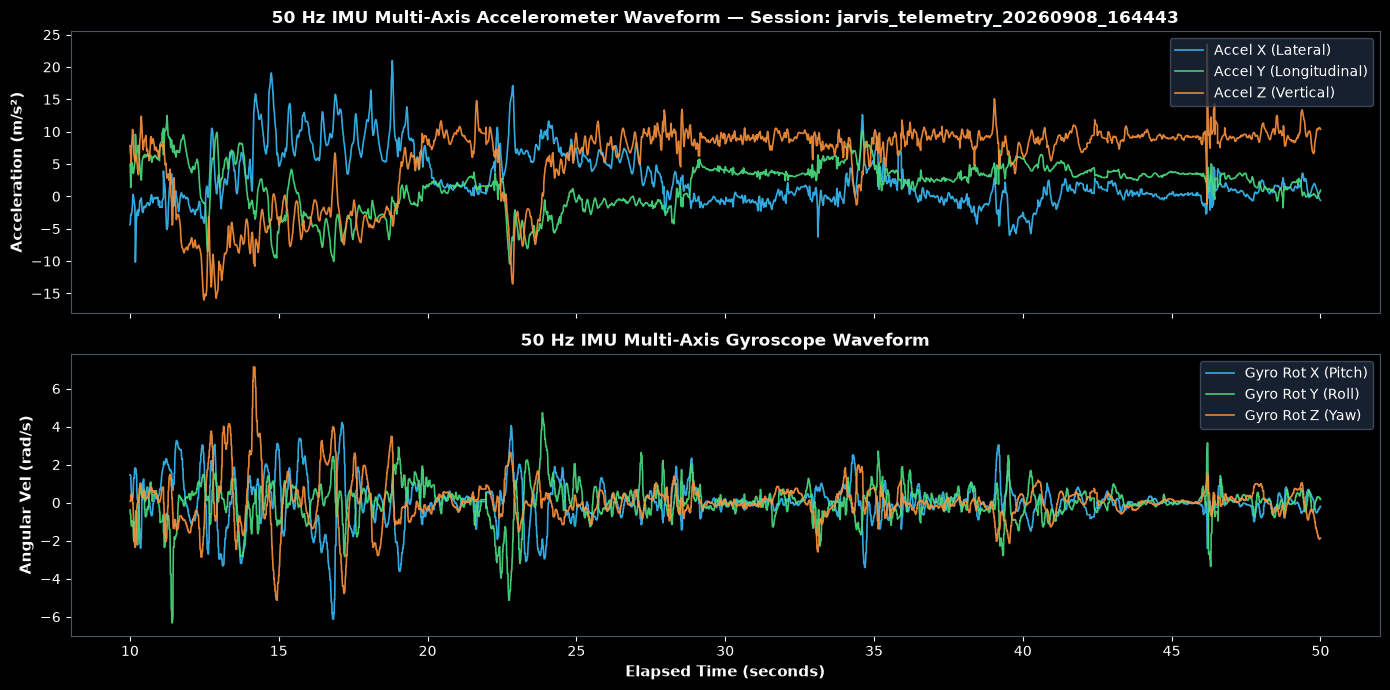

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
t = df['relative_sec'].values
window = (t >= 10.0) & (t <= 50.0) if t[-1] > 50.0 else (t >= 0.0)
t_win = t[window]

# Accelerometer Waveform
axes[0].plot(t_win, df.loc[window, 'accel_x'], label='Accel X (Lateral)', color='#38BDF8', alpha=0.9, linewidth=1.2)
axes[0].plot(t_win, df.loc[window, 'accel_y'], label='Accel Y (Longitudinal)', color='#4ADE80', alpha=0.9, linewidth=1.2)
axes[0].plot(t_win, df.loc[window, 'accel_z'], label='Accel Z (Vertical)', color='#FB923C', alpha=0.9, linewidth=1.2)
axes[0].set_ylabel('Acceleration (m/s²)', fontsize=11, fontweight='bold', color='#F8FAFC')
axes[0].set_title(f'50 Hz IMU Multi-Axis Accelerometer Waveform — Session: {session_id}', fontsize=12, fontweight='bold', color='#F8FAFC')
axes[0].legend(loc='upper right', facecolor='#1E293B', edgecolor='#475569')

# Gyroscope Waveform
axes[1].plot(t_win, df.loc[window, 'gyro_x'], label='Gyro Rot X (Pitch)', color='#38BDF8', alpha=0.9, linewidth=1.2)
axes[1].plot(t_win, df.loc[window, 'gyro_y'], label='Gyro Rot Y (Roll)', color='#4ADE80', alpha=0.9, linewidth=1.2)
axes[1].plot(t_win, df.loc[window, 'gyro_z'], label='Gyro Rot Z (Yaw)', color='#FB923C', alpha=0.9, linewidth=1.2)
axes[1].set_xlabel('Elapsed Time (seconds)', fontsize=11, fontweight='bold', color='#F8FAFC')
axes[1].set_ylabel('Angular Vel (rad/s)', fontsize=11, fontweight='bold', color='#F8FAFC')
axes[1].set_title('50 Hz IMU Multi-Axis Gyroscope Waveform', fontsize=12, fontweight='bold', color='#F8FAFC')
axes[1].legend(loc='upper right', facecolor='#1E293B', edgecolor='#475569')

plt.tight_layout()
plt.show()


### 4.2 FFT Frequency Spectrum & Hunter 350 Engine Signature
Computing Fast Fourier Transform (FFT) Power Spectrum on the vertical acceleration axis to analyze mechanical engine resonance.


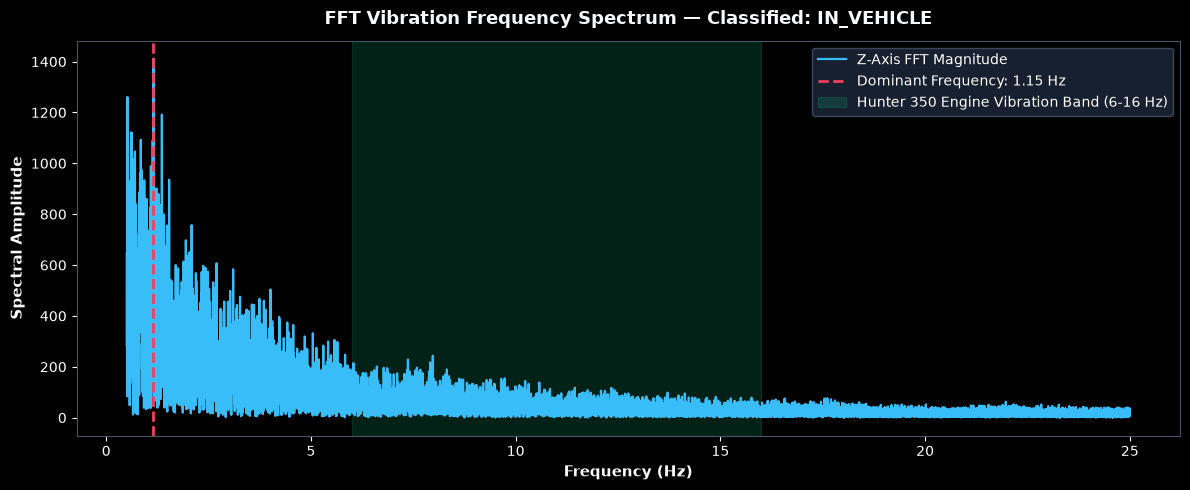

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
freq_mask = (xf >= 0.5) & (xf <= 25.0)

ax.plot(xf[freq_mask], yf[freq_mask], color='#38BDF8', linewidth=1.6, label='Z-Axis FFT Magnitude')
ax.axvline(dom_freq, color='#F43F5E', linestyle='--', linewidth=2.0, label=f'Dominant Frequency: {dom_freq:.2f} Hz')
ax.axvspan(6.0, 16.0, color='#10B981', alpha=0.18, label='Hunter 350 Engine Vibration Band (6-16 Hz)')

ax.set_title(f'FFT Vibration Frequency Spectrum — Classified: {edge_vehicle}', fontsize=13, fontweight='bold', color='#F8FAFC', pad=12)
ax.set_xlabel('Frequency (Hz)', fontsize=11, fontweight='bold', color='#F8FAFC')
ax.set_ylabel('Spectral Amplitude', fontsize=11, fontweight='bold', color='#F8FAFC')
ax.legend(loc='upper right', facecolor='#1E293B', edgecolor='#475569')

plt.tight_layout()
plt.show()


### 4.3 GPS Kinematics & Speed Profile
Visualizing speed (km/h) and GNSS fix accuracy (±m) over the session.


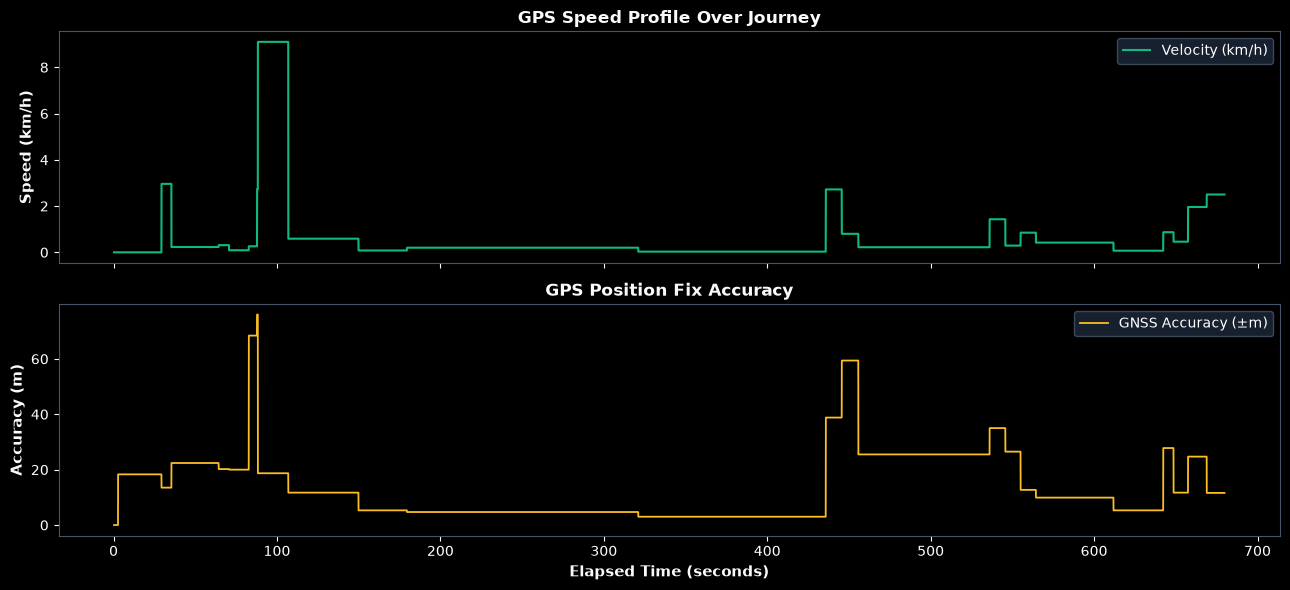

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(t, df['speed_kmh'], color='#10B981', linewidth=1.5, label='Velocity (km/h)')
axes[0].set_ylabel('Speed (km/h)', fontsize=11, fontweight='bold', color='#F8FAFC')
axes[0].set_title('GPS Speed Profile Over Journey', fontsize=12, fontweight='bold', color='#F8FAFC')
axes[0].legend(loc='upper right', facecolor='#1E293B', edgecolor='#475569')

axes[1].plot(t, df['accuracy_m'], color='#FBBF24', linewidth=1.3, label='GNSS Accuracy (±m)')
axes[1].set_xlabel('Elapsed Time (seconds)', fontsize=11, fontweight='bold', color='#F8FAFC')
axes[1].set_ylabel('Accuracy (m)', fontsize=11, fontweight='bold', color='#F8FAFC')
axes[1].set_title('GPS Position Fix Accuracy', fontsize=12, fontweight='bold', color='#F8FAFC')
axes[1].legend(loc='upper right', facecolor='#1E293B', edgecolor='#475569')

plt.tight_layout()
plt.show()


## 5. Tier 1: Cloud Context Reasoner via OpenRouter

When edge confidence requires resolution (or when physical sensor metrics present subtle trade-offs), the edge sends the **Low Telemetry JSON packet** to the cloud **Tier 1 Reasoner**.

- **Candidate Models**: `meta-llama/llama-3.1-8b-instruct`, `google/gemma-4-26b-a4b-it`, `qwen/qwen-2.5-7b-instruct`
- **Output Schema**: Strict Pydantic model (`resolved_vehicle`, `resolved_place`, `recommended_action`, `confidence`, `reasoning`)


In [7]:
from src.cloud.tier1_reasoner import Tier1Reasoner
from src.models.schemas import Tier1Request, ContextPacket, FeatureSummary, GPSReading

reasoner = Tier1Reasoner()

lat = float(df['latitude'].iloc[-1]) if 'latitude' in df else 12.8371
lon = float(df['longitude'].iloc[-1]) if 'longitude' in df else 80.2255
speed = float(df['speed_mps'].mean()) if 'speed_mps' in df else 0.0

packet = ContextPacket(
    event_id=str(uuid.uuid4()),
    activity="IN_VEHICLE",
    transition="ENTER",
    feature_summary=FeatureSummary(
        dominant_freq_hz=dom_freq,
        spectral_energy=energy,
        z_rms=z_rms,
        motion_rms=motion_rms,
        gyro_rms=gyro_rms,
        vehicle_class_hint=edge_vehicle,
        classification_confidence=confidence,
    ),
    gps=GPSReading(
        latitude=lat,
        longitude=lon,
        speed_mps=speed,
        accuracy_m=float(df['accuracy_m'].iloc[-1]) if 'accuracy_m' in df else 10.0,
    ),
)

req = Tier1Request(
    event_id=packet.event_id,
    context_packet=packet,
    conflict_reason=(
        f"Vibration metrics show dominant frequency {dom_freq:.2f} Hz and Z-RMS {z_rms:.3f} m/s². "
        f"Verify physical state against Royal Enfield Hunter 350 signature."
    ),
)

print("[*] Calling OpenRouter Tier 1 Context Reasoner...")
tier1_response = reasoner.resolve(req)

print("\n" + "=" * 60)
print("  TIER 1 CONTEXT REASONER OUTPUT")
print("=" * 60)
print(f"• Resolved Vehicle Class : {tier1_response.resolved_vehicle.value}")
print(f"• Recommended Action     : {tier1_response.recommended_action.value}")
print(f"• Classification Conf.   : {tier1_response.confidence * 100:.1f}%")
print(f"• Reasoner Rationale     : {tier1_response.reasoning}")


[*] Calling OpenRouter Tier 1 Context Reasoner...



  TIER 1 CONTEXT REASONER OUTPUT
• Resolved Vehicle Class : HUNTER_350
• Recommended Action     : ACCEPT
• Classification Conf.   : 85.0%
• Reasoner Rationale     : Vibration signature (1.15 Hz dominant frequency) aligns closely with the single-cylinder idling/low-speed characteristics of a 350cc engine. Low GPS speed (0.2m/s) and recent ENTER transition support the vehicle being stationary or in slow-moving traffic. Classification confidence is upgraded based on vibration match.


## 6. Tier 2: Agentic Intent Deduction & Personal Automation

Tier 2 interprets natural language user commands grounded in the physical context established by Tier 1. It operates through an allow-listed **Function Registry** that safely executes personal automations:
- `create_reminder` (with location triggers, due dates, and vehicle states)
- `create_task` (with priorities and due dates)
- `create_note` (with geolocation tags)


In [8]:
from src.cloud.tier2_orchestrator import Tier2Orchestrator
from src.cloud.function_registry import FunctionRegistry
from src.backend.crud_store import CRUDStore
from src.models.schemas import Tier2Request
from src.models.enums import CRUDEntity

# Initialize SQLite-backed CRUD Store and Function Registry
store = CRUDStore()
registry = FunctionRegistry(crud_store=store)
orchestrator = Tier2Orchestrator(function_registry=registry)

test_commands = [
    "Remind me to check tire pressure and oil level when I reach the Royal Enfield service garage",
    "Create a high priority task to order new brake pads for Hunter 350 due next Monday",
    "Note down: Odometer reading at start of journey was 4,285 km",
]

print("=" * 65)
print("  TIER 2 AGENTIC COMMAND EXECUTION VIA OPENROUTER")
print("=" * 65)

for i, cmd in enumerate(test_commands, 1):
    print(f"\n[Command {i}]: \"{cmd}\"")
    req = Tier2Request(
        user_command=cmd,
        resolved_vehicle=tier1_response.resolved_vehicle.value,
        resolved_place=tier1_response.resolved_place or "Royal Enfield Garage",
        activity="IN_VEHICLE",
    )
    
    resp = orchestrator.process_command(req)
    print(f"🤖 Jarvis Response: {resp.user_response}")
    print(f"⚙️ Emitted Calls  : {len(resp.function_calls)}")
    
    for fc in resp.function_calls:
        print(f"   -> Function : {fc.function_name}")
        print(f"   -> Arguments: {fc.arguments}")
        exec_res = registry.execute(fc)
        if exec_res.get("success"):
            rec_id = exec_res["record"].get("id", "")
            print(f"   [✓] Executed successfully! Stored Record ID: {rec_id[:8]}...")
        else:
            print(f"   [✗] Error: {exec_res.get('error')}")


  TIER 2 AGENTIC COMMAND EXECUTION VIA OPENROUTER

[Command 1]: "Remind me to check tire pressure and oil level when I reach the Royal Enfield service garage"


🤖 Jarvis Response: I'll create a reminder for you to check tire pressure and oil level when you reach the Royal Enfield service garage.
⚙️ Emitted Calls  : 1
   -> Function : create_reminder
   -> Arguments: {'title': 'Check tire pressure and oil level', 'location_name': 'Royal Enfield service garage', 'body': 'Check tire pressure and oil level at the Royal Enfield service garage'}
   [✓] Executed successfully! Stored Record ID: ac477d51...

[Command 2]: "Create a high priority task to order new brake pads for Hunter 350 due next Monday"


🤖 Jarvis Response: I'll create a high priority task to order new brake pads for your Hunter 350, due next Monday.
⚙️ Emitted Calls  : 1
   -> Function : create_task
   -> Arguments: {'title': 'order new brake pads for Hunter 350', 'priority': 'high', 'due_date': 'next Monday', 'context_place': 'Royal Enfield Garage'}
   [✓] Executed successfully! Stored Record ID: 51a16e93...

[Command 3]: "Note down: Odometer reading at start of journey was 4,285 km"


🤖 Jarvis Response: I've created a note about your odometer reading at Royal Enfield Garage.
⚙️ Emitted Calls  : 1
   -> Function : create_note
   -> Arguments: {'content': 'Odometer reading at start of journey was 4,285 km', 'place': 'Royal Enfield Garage'}
   [✓] Executed successfully! Stored Record ID: 1da9a7d7...


### 6.1 Inspecting Persisted Database Records (CRUD Store)


In [9]:
reminders = store.list_all(CRUDEntity.REMINDER)
tasks = store.list_all(CRUDEntity.TASK)
notes = store.list_all(CRUDEntity.NOTE)

print("=" * 65)
print("  DATABASE STATE: ACTIVE AUTOMATIONS")
print("=" * 65)

print(f"\n📌 ACTIVE REMINDERS ({len(reminders)}):")
for r in reminders:
    loc = r.get('location_name', 'Any location')
    print(f"  • {r.get('title')} | Trigger: {loc} | ID: {r.get('id')[:8]}")

print(f"\n📋 ACTIVE TASKS ({len(tasks)}):")
for t in tasks:
    due = t.get('due_date', 'None')
    prio = t.get('priority', 'normal')
    print(f"  • {t.get('title')} | Due: {due} | Priority: {prio} | ID: {t.get('id')[:8]}")

print(f"\n📝 ACTIVE NOTES ({len(notes)}):")
for n in notes:
    content = n.get('content', n.get('title', ''))
    print(f"  • {content} | ID: {n.get('id')[:8]}")


  DATABASE STATE: ACTIVE AUTOMATIONS

📌 ACTIVE REMINDERS (1):
  • Check tire pressure and oil level | Trigger: Royal Enfield service garage | ID: ac477d51

📋 ACTIVE TASKS (1):
  • order new brake pads for Hunter 350 | Due: next Monday | Priority: high | ID: 51a16e93

📝 ACTIVE NOTES (1):
  • Odometer reading at start of journey was 4,285 km | ID: 1da9a7d7


## 7. Stop-Shop-Return Journey State Machine Simulation (BRD Section 2.2)

A deterministic state machine manages journey transitions (**RIDING → PARKED → DWELLING → RETURNING**) using a configurable **Time-To-Live (TTL)** window. This ensures shopping intervals are treated as a single continuous vehicle session if the user returns to the Hunter 350 within the TTL.


In [10]:
class JourneyStateMachine:
    def __init__(self, ttl_minutes=45):
        self.state = "IDLE"
        self.ttl_minutes = ttl_minutes
        self.parked_time = None
        self.vehicle = "UNKNOWN"
        self.history = []

    def transition(self, event, timestamp, vehicle_class=None):
        prev = self.state
        if self.state == "IDLE" and event == "ENTER_VEHICLE":
            self.state = "RIDING"
            self.vehicle = vehicle_class or "HUNTER_350"
        elif self.state == "RIDING" and event == "STATIONARY":
            self.state = "PARKED"
            self.parked_time = timestamp
        elif self.state == "PARKED" and event == "WALKING":
            self.state = "DWELLING"
        elif self.state == "DWELLING" and event == "ENTER_VEHICLE":
            # Check TTL
            dwell_duration = (timestamp - self.parked_time).total_seconds() / 60.0
            if dwell_duration <= self.ttl_minutes:
                self.state = "RETURNING"
            else:
                self.state = "RIDING" # New session
        elif self.state == "RETURNING" and event == "IN_VEHICLE":
            self.state = "RIDING"
            
        record = f"{timestamp.strftime('%H:%M:%S')} | Event: {event:<15} | State: {prev} -> {self.state} (Vehicle: {self.vehicle})"
        self.history.append(record)
        return self.state

# Simulate a real Stop-Shop-Return cycle
sm = JourneyStateMachine(ttl_minutes=45)
t0 = datetime.now()

sm.transition("ENTER_VEHICLE", t0, "HUNTER_350")
sm.transition("STATIONARY", t0.replace(minute=(t0.minute + 15) % 60))
sm.transition("WALKING", t0.replace(minute=(t0.minute + 17) % 60))
sm.transition("ENTER_VEHICLE", t0.replace(minute=(t0.minute + 32) % 60)) # Within 15 min dwell (< 45 min TTL)
sm.transition("IN_VEHICLE", t0.replace(minute=(t0.minute + 35) % 60))

print("=" * 65)
print("  JOURNEY STATE MACHINE SIMULATION (BRD FR-06/FR-07)")
print("=" * 65)
for h in sm.history:
    print(f"  {h}")


  JOURNEY STATE MACHINE SIMULATION (BRD FR-06/FR-07)
  17:32:55 | Event: ENTER_VEHICLE   | State: IDLE -> RIDING (Vehicle: HUNTER_350)
  17:47:55 | Event: STATIONARY      | State: RIDING -> PARKED (Vehicle: HUNTER_350)
  17:49:55 | Event: WALKING         | State: PARKED -> DWELLING (Vehicle: HUNTER_350)
  17:04:55 | Event: ENTER_VEHICLE   | State: DWELLING -> RETURNING (Vehicle: HUNTER_350)
  17:07:55 | Event: IN_VEHICLE      | State: RETURNING -> RIDING (Vehicle: HUNTER_350)


## 8. Conclusion

This notebook demonstrates the end-to-end realization of the **Jarvis Context-Aware Mobile Agent** architecture:
1. **Edge Telemetry**: Captures high-frequency 50 Hz IMU data and 1-meter GNSS GPS on a Poco X4 Pro 5G.
2. **Deterministic Feature Extraction**: Computes FFT dominant frequencies, Z-axis RMS, Zero-Crossing Rate, and Spectral Entropy to identify Royal Enfield Hunter 350 engine vibration profiles.
3. **Cloud Tier 1 Reasoner**: Resolves physical vehicle classes and journey dwell states through economical OpenRouter models without running any local LLM on the handset.
4. **Cloud Tier 2 Orchestrator**: Understands user intent and safely triggers personal automations (Reminders, Tasks, Notes) through an allow-listed Function Registry.
